# 00 - Radiografia de Cobertura de Quotes por Ticker

Objetivo:
- Medir cobertura real de `quotes` por ticker sobre la ventana activa del universo (`03_time_coverage_v3`).
- Cuantificar cuantos tickers tienen 100% de cobertura y donde estan las carencias.
- Mostrar resultados de forma didactica con graficos y metricas matematicas.

Nota de transparencia:
- En este workspace, `data/reference/official_lifecycle_compiled.csv` contiene solo 1 ticker (`AABA`).
- Para cobertura masiva (4777 tickers) se usa la ventana operativa del pipeline v3: meses OHLCV disponibles por ticker (misma logica de `03_time_coverage_v3`).
- Si luego se repuebla lifecycle oficial completo, este notebook queda listo para enchufarlo como expected window adicional.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


In [2]:
# --- Paths base ---
PROJECT_ROOT = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps')
DATA_ROOT = Path(r'C:\TSIS_Data\data')

assert PROJECT_ROOT.exists(), f'No existe PROJECT_ROOT: {PROJECT_ROOT}'
assert DATA_ROOT.exists(), f'No existe DATA_ROOT: {DATA_ROOT}'

RUNS_V3_ROOT = PROJECT_ROOT / 'runs' / 'data_quality' / '03_time_coverage_v3'
run_dirs = sorted([p for p in RUNS_V3_ROOT.iterdir() if p.is_dir() and 'prefilter_v3_multi_era' in p.name])
assert run_dirs, f'No se encontraron runs en {RUNS_V3_ROOT}'
LATEST_V3_RUN = run_dirs[-1]

EVIDENCE_PATH = LATEST_V3_RUN / '03_ticker_evidence_v3.parquet'
SUMMARY_PATH = LATEST_V3_RUN / '03_universe_prefilter_v3_summary.json'

OFFICIAL_LIFECYCLE_CSV = PROJECT_ROOT / 'data' / 'reference' / 'official_lifecycle_compiled.csv'
OFFICIAL_EVENTS_CSV = PROJECT_ROOT / 'data' / 'reference' / 'official_ticker_events.csv'

CACHE_DIR = PROJECT_ROOT / 'runs' / 'backtest' / '02_policy_integration' / 'coverage_radiography'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / f'quotes_coverage_by_ticker_{LATEST_V3_RUN.name}.parquet'

print('LATEST_V3_RUN:', LATEST_V3_RUN)
print('EVIDENCE_PATH :', EVIDENCE_PATH)
print('SUMMARY_PATH  :', SUMMARY_PATH)
print('CACHE_PATH    :', CACHE_PATH)


LATEST_V3_RUN: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage_v3\20260226_105711_prefilter_v3_multi_era
EVIDENCE_PATH : C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage_v3\20260226_105711_prefilter_v3_multi_era\03_ticker_evidence_v3.parquet
SUMMARY_PATH  : C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage_v3\20260226_105711_prefilter_v3_multi_era\03_universe_prefilter_v3_summary.json
CACHE_PATH    : C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\coverage_radiography\quotes_coverage_by_ticker_20260226_105711_prefilter_v3_multi_era.parquet


In [3]:
# --- Contexto de artefactos oficiales/reportados ---
with open(SUMMARY_PATH, 'r', encoding='utf-8') as f:
    v3_summary = json.load(f)

evidence = pd.read_parquet(EVIDENCE_PATH)

official_lifecycle = pd.read_csv(OFFICIAL_LIFECYCLE_CSV) if OFFICIAL_LIFECYCLE_CSV.exists() else pd.DataFrame()
official_events = pd.read_csv(OFFICIAL_EVENTS_CSV) if OFFICIAL_EVENTS_CSV.exists() else pd.DataFrame()

print('Universe (v3) tickers:', evidence['ticker'].nunique())
print('Rows evidence v3    :', len(evidence))
print('Official lifecycle rows/tickers:', len(official_lifecycle), '/', official_lifecycle['ticker'].nunique() if 'ticker' in official_lifecycle.columns else 0)
print('Official events rows/tickers   :', len(official_events), '/', official_events['ticker'].nunique() if 'ticker' in official_events.columns else 0)

display(pd.DataFrame([
    {
        'n_universe_input': v3_summary.get('n_universe_input'),
        'n_eligible': v3_summary.get('n_eligible'),
        'n_manual_review': v3_summary.get('n_manual_review'),
        'n_excluded': v3_summary.get('n_excluded')
    }
]))


n_universe_input,n_eligible,n_manual_review,n_excluded
4777,1687,3090,0


Universe (v3) tickers: 4777
Rows evidence v3    : 4777
Official lifecycle rows/tickers: 1 / 1
Official events rows/tickers   : 3 / 1


## Definicion matematica de cobertura (este notebook)

Para cada ticker `t`:
- `O_months(t)`: meses con OHLCV disponible (ventana activa del pipeline).
- `Q_days(t, m)`: numero de dias con `quotes.parquet` en mes `m`.
- `E_days(m)`: dias habiles NYSE esperados en mes `m` (calendario oficial).

Se define:
- `ExpectedDays(t) = sum_{m in O_months(t)} E_days(m)`
- `ObservedQuoteDays(t) = sum_{m in O_months(t)} Q_days(t, m)`
- `Coverage(t) = ObservedQuoteDays(t) / ExpectedDays(t)`

Interpretacion:
- `Coverage = 1.0` -> ticker con quotes completos en toda su ventana activa.
- `Coverage < 1.0` -> faltantes de quotes (carencias).
- `MissingDays = ExpectedDays - ObservedQuoteDays`.


In [4]:
# --- Utilidades de escaneo filesystem (sin leer parquet completo) ---
def _iter_year_dirs(base: Path, ticker: str) -> Iterable[Path]:
    p = base / ticker
    if not p.exists():
        return []
    return [y for y in p.glob('year=*') if y.is_dir()]

def quote_month_to_days(quote_roots: Tuple[Path, ...], ticker: str) -> Dict[Tuple[int, int], int]:
    out: Dict[Tuple[int, int], int] = {}
    for qroot in quote_roots:
        for y in _iter_year_dirs(qroot, ticker):
            try:
                yy = int(y.name.split('=', 1)[1])
            except Exception:
                continue
            for m in y.glob('month=*'):
                if not m.is_dir():
                    continue
                try:
                    mm = int(m.name.split('=', 1)[1])
                except Exception:
                    continue
                n_days = sum(1 for _ in m.glob('day=*/quotes.parquet'))
                if n_days <= 0:
                    continue
                k = (yy, mm)
                out[k] = max(out.get(k, 0), n_days)
    return out

def ohlcv_months(ohlcv_root: Path, ticker: str) -> set[Tuple[int, int]]:
    out: set[Tuple[int, int]] = set()
    for y in _iter_year_dirs(ohlcv_root, ticker):
        try:
            yy = int(y.name.split('=', 1)[1])
        except Exception:
            continue
        for m in y.glob('month=*'):
            if not m.is_dir():
                continue
            try:
                mm = int(m.name.split('=', 1)[1])
            except Exception:
                continue
            if (m / 'minute.parquet').exists():
                out.add((yy, mm))
    return out

eras = [
    {
        'name': '2004_2018',
        'ohlcv_root': DATA_ROOT / 'ohlcv_intraday_1m' / '2004_2018',
        'quote_roots': (DATA_ROOT / 'quotes_p95_2004_2018',),
    },
    {
        'name': '2019_2025',
        'ohlcv_root': DATA_ROOT / 'ohlcv_intraday_1m' / '2019_2025',
        'quote_roots': (DATA_ROOT / 'quotes_p95_2019_2025', DATA_ROOT / 'quotes_p95'),
    },
]

for e in eras:
    assert e['ohlcv_root'].exists(), f"No existe {e['ohlcv_root']}"
    for qr in e['quote_roots']:
        assert qr.exists(), f"No existe {qr}"


In [5]:
# --- Construccion / carga de cobertura por ticker ---
# Para performance: cacheamos a parquet la tabla final por run_tag.
required_cache_cols = {
    'ticker', 'expected_days', 'observed_quote_days', 'observed_quote_days_raw', 'extra_days_vs_calendar',
    'missing_days', 'coverage_ratio', 'o_months_total_fs', 'q_months_total_fs'
}

cache_ok = False
if CACHE_PATH.exists():
    cov = pd.read_parquet(CACHE_PATH)
    cache_ok = required_cache_cols.issubset(set(cov.columns))
    if cache_ok:
        print('Cache cargada:', CACHE_PATH)
    else:
        print('Cache encontrada pero incompleta; se recalcula:', CACHE_PATH)

if not cache_ok:
    try:
        import exchange_calendars as xcals
    except Exception as e:
        raise RuntimeError('Falta exchange_calendars. Instalar para computar ExpectedDays exacto por mes NYSE.') from e

    cal = xcals.get_calendar('XNYS')
    sched = cal.schedule.loc['2004-01-01':'2025-12-31'].copy()
    sched['ym'] = list(zip(sched.index.year, sched.index.month))
    expected_days_by_month = sched.groupby('ym').size().to_dict()

    rows = []
    tickers = evidence['ticker'].dropna().astype(str).sort_values().unique().tolist()

    for i, t in enumerate(tickers, start=1):
        all_o_months: set[Tuple[int, int]] = set()
        all_q_month_days: Dict[Tuple[int, int], int] = {}

        for era in eras:
            o_set = ohlcv_months(era['ohlcv_root'], t)
            q_map = quote_month_to_days(era['quote_roots'], t)

            all_o_months |= o_set
            for k, v in q_map.items():
                all_q_month_days[k] = max(all_q_month_days.get(k, 0), v)

        expected_days = int(sum(expected_days_by_month.get(m, 0) for m in all_o_months))
        observed_quote_days_raw = int(sum(all_q_month_days.get(m, 0) for m in all_o_months))
        observed_quote_days_capped = int(sum(min(all_q_month_days.get(m, 0), expected_days_by_month.get(m, 0)) for m in all_o_months))
        extra_days_vs_calendar = max(observed_quote_days_raw - observed_quote_days_capped, 0)
        observed_quote_days = observed_quote_days_capped
        missing_days = max(expected_days - observed_quote_days, 0)
        coverage_ratio = (observed_quote_days / expected_days) if expected_days > 0 else np.nan

        rows.append({
            'ticker': t,
            'expected_days': expected_days,
            'observed_quote_days': observed_quote_days,
            'observed_quote_days_raw': observed_quote_days_raw,
            'extra_days_vs_calendar': extra_days_vs_calendar,
            'missing_days': missing_days,
            'coverage_ratio': coverage_ratio,
            'o_months_total_fs': len(all_o_months),
            'q_months_total_fs': int(sum(1 for m in all_o_months if all_q_month_days.get(m, 0) > 0)),
        })

        if i % 500 == 0:
            print(f'Procesados {i}/{len(tickers)} tickers...')

    cov = pd.DataFrame(rows)
    cov = cov.merge(
        evidence[['ticker', 'prefilter_decision', 'prefilter_reason', 'o_months_total', 'q_months_total', 'overlap_months_total', 'overlap_quote_days_total']],
        on='ticker',
        how='left'
    )
    cov.to_parquet(CACHE_PATH, index=False)
    print('Cache guardada en:', CACHE_PATH)

cov.head()


Cache cargada: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\coverage_radiography\quotes_coverage_by_ticker_20260226_105711_prefilter_v3_multi_era.parquet


In [6]:
# --- Buckets didacticos y metricas resumen ---
cov = cov.copy()
cov['coverage_pct'] = cov['coverage_ratio'] * 100.0

def bucket(p: float) -> str:
    if pd.isna(p):
        return 'sin_expected_window'
    if p >= 99.999999:
        return '100%'
    if p >= 95.0:
        return '[95,100)'
    if p >= 80.0:
        return '[80,95)'
    if p >= 50.0:
        return '[50,80)'
    if p > 0.0:
        return '(0,50)'
    return '0%'

cov['coverage_bucket'] = cov['coverage_pct'].map(bucket)

n = len(cov)
n_100 = int((cov['coverage_bucket'] == '100%').sum())
n_zero = int((cov['coverage_bucket'] == '0%').sum())

summary_math = pd.DataFrame([{
    'tickers_total': n,
    'tickers_100pct': n_100,
    'pct_100pct': round(100 * n_100 / n, 4),
    'tickers_0pct': n_zero,
    'pct_0pct': round(100 * n_zero / n, 4),
    'coverage_mean_pct': round(cov['coverage_pct'].mean(skipna=True), 4),
    'coverage_median_pct': round(cov['coverage_pct'].median(skipna=True), 4),
    'missing_days_total': int(cov['missing_days'].sum(skipna=True)),
    'observed_quote_days_total': int(cov['observed_quote_days'].sum(skipna=True)),
    'expected_days_total': int(cov['expected_days'].sum(skipna=True)),
}])

display(summary_math)
display(cov['coverage_bucket'].value_counts(dropna=False).rename_axis('bucket').reset_index(name='n_tickers'))


tickers_total,tickers_100pct,pct_100pct,tickers_0pct,pct_0pct,coverage_mean_pct,coverage_median_pct,missing_days_total,observed_quote_days_total,expected_days_total
4777,4,0.0837,13,0.2721,6.2326,1.2066,6599516,352603,6952119


bucket,n_tickers
"(0,50)",4627
"[50,80)",79
"[80,95)",30
"[95,100)",24
0%,13
100%,4


<string>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


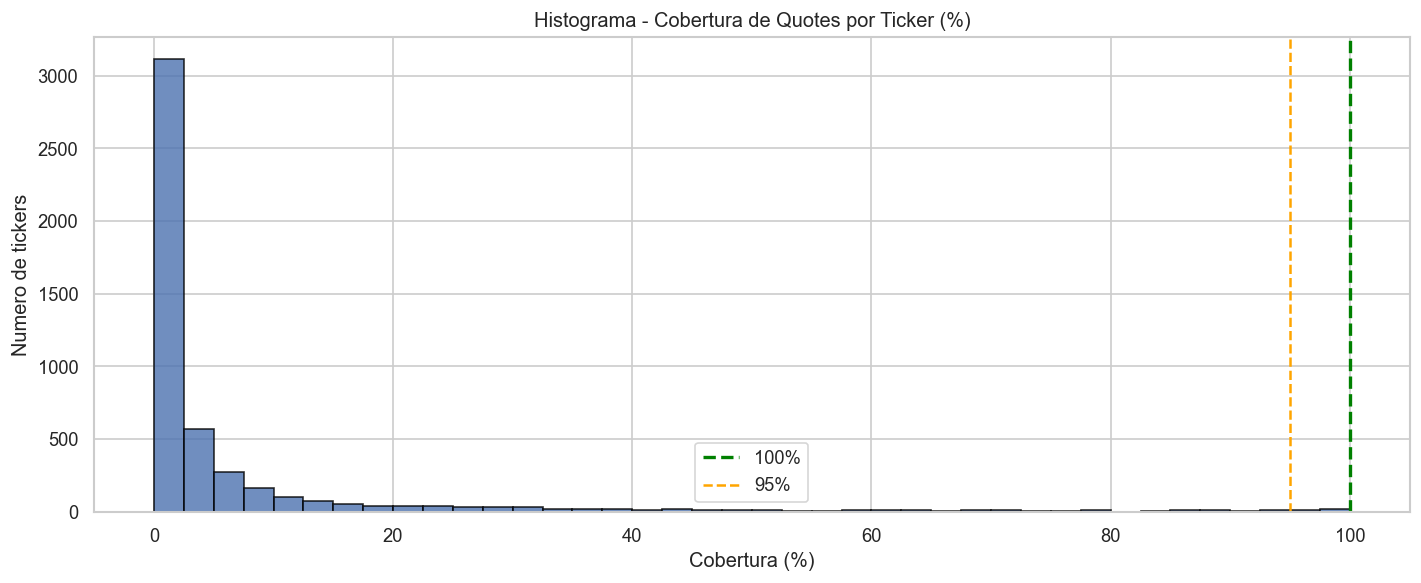

In [7]:
# --- Histograma de cobertura (%) ---
plt.figure(figsize=(12, 5))
vals = cov['coverage_pct'].replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(vals, bins=np.linspace(0, 100, 41), edgecolor='black', alpha=0.8)
plt.title('Histograma - Cobertura de Quotes por Ticker (%)')
plt.xlabel('Cobertura (%)')
plt.ylabel('Numero de tickers')
plt.axvline(100, color='green', linestyle='--', linewidth=2, label='100%')
plt.axvline(95, color='orange', linestyle='--', linewidth=1.5, label='95%')
plt.legend()
plt.tight_layout()
plt.show()


bucket,n_tickers
100%,4
"[95,100)",24
"[80,95)",30
"[50,80)",79
"(0,50)",4627
0%,13
sin_expected_window,0


<string>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


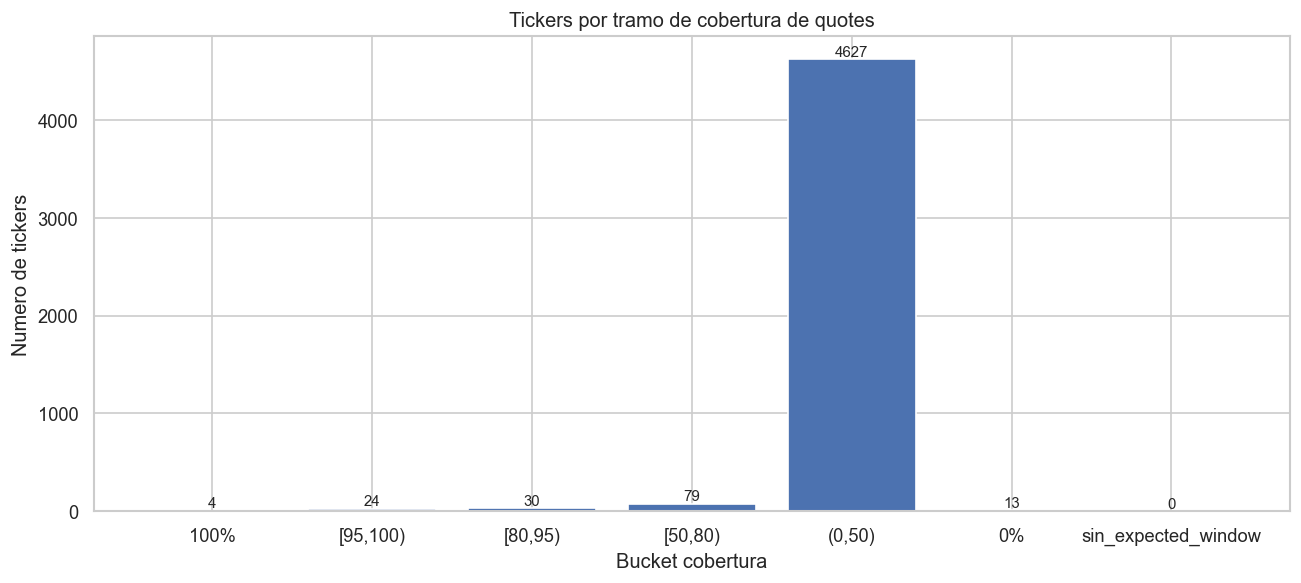

In [8]:
# --- Barras por bucket (incluye 100%) ---
bucket_order = ['100%', '[95,100)', '[80,95)', '[50,80)', '(0,50)', '0%', 'sin_expected_window']
bucket_counts = (
    cov['coverage_bucket']
    .value_counts()
    .reindex(bucket_order, fill_value=0)
    .rename_axis('bucket')
    .reset_index(name='n_tickers')
)

plt.figure(figsize=(11, 5))
plt.bar(bucket_counts['bucket'], bucket_counts['n_tickers'])
plt.title('Tickers por tramo de cobertura de quotes')
plt.xlabel('Bucket cobertura')
plt.ylabel('Numero de tickers')
for i, v in enumerate(bucket_counts['n_tickers']):
    plt.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

display(bucket_counts)


In [9]:
# --- Carencias: top tickers con mas dias faltantes ---
worst = cov.sort_values(['missing_days', 'expected_days'], ascending=[False, False]).head(30)
display(worst[['ticker', 'coverage_pct', 'expected_days', 'observed_quote_days', 'missing_days', 'prefilter_decision', 'prefilter_reason']])

# Relacion con decision de policy
decision_bucket = (
    cov.groupby(['prefilter_decision', 'coverage_bucket'], dropna=False)['ticker']
    .count()
    .rename('n_tickers')
    .reset_index()
    .sort_values(['prefilter_decision', 'n_tickers'], ascending=[True, False])
)
display(decision_bucket.head(40))


ticker,coverage_pct,expected_days,observed_quote_days,missing_days,prefilter_decision,prefilter_reason
HURC,0.000000,4970,0,4970,manual_review,low_overlap_months
ITRN,0.000000,4970,0,4970,manual_review,low_overlap_months
NGS,0.000000,4970,0,4970,manual_review,low_overlap_months
NL,0.000000,4970,0,4970,manual_review,low_overlap_months
OXM,0.000000,4970,0,4970,manual_review,low_overlap_months
SCSC,0.000000,4970,0,4970,manual_review,low_overlap_quote_days
TACT,0.000000,4970,0,4970,manual_review,low_overlap_months
TAYD,0.000000,4970,0,4970,manual_review,low_overlap_quote_days
AIN,0.020121,4970,1,4969,manual_review,low_overlap_months
AIRT,0.020121,4970,1,4969,eligible,eligible_overlap_multi_era


prefilter_decision,coverage_bucket,n_tickers
eligible,"(0,50)",1552
eligible,"[50,80)",76
eligible,"[80,95)",30
eligible,"[95,100)",24
eligible,100%,3
eligible,0%,2
manual_review,"(0,50)",3075
manual_review,0%,11
manual_review,"[50,80)",3
manual_review,100%,1


In [10]:
# --- Exportables para auditoria externa ---
out_csv = CACHE_DIR / f'quotes_coverage_by_ticker_{LATEST_V3_RUN.name}.csv'
out_bucket = CACHE_DIR / f'quotes_coverage_bucket_counts_{LATEST_V3_RUN.name}.csv'
out_summary = CACHE_DIR / f'quotes_coverage_summary_{LATEST_V3_RUN.name}.json'

cov.sort_values('coverage_ratio', ascending=False).to_csv(out_csv, index=False)
bucket_counts.to_csv(out_bucket, index=False)
with open(out_summary, 'w', encoding='utf-8') as f:
    json.dump(summary_math.iloc[0].to_dict(), f, ensure_ascii=True, indent=2)

print('Exportado:')
print('-', out_csv)
print('-', out_bucket)
print('-', out_summary)


Exportado:
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\coverage_radiography\quotes_coverage_by_ticker_20260226_105711_prefilter_v3_multi_era.csv
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\coverage_radiography\quotes_coverage_bucket_counts_20260226_105711_prefilter_v3_multi_era.csv
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\02_policy_integration\coverage_radiography\quotes_coverage_summary_20260226_105711_prefilter_v3_multi_era.json
